## Load the dataset

In [2]:
pip install scipy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
from scipy.io import arff

In [4]:
data, meta = arff.loadarff('Rice_Cammeo_Osmancik.arff')

In [5]:
print(meta)

Dataset: Rice_Cammeo_Osmancik
	Area's type is numeric
	Perimeter's type is numeric
	Major_Axis_Length's type is numeric
	Minor_Axis_Length's type is numeric
	Eccentricity's type is numeric
	Convex_Area's type is numeric
	Extent's type is numeric
	Class's type is nominal, range is ('Cammeo', 'Osmancik')



In [6]:
df = pd.DataFrame(data)

In [7]:
df.head()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
0,15231.0,525.578979,229.749878,85.093788,0.928882,15617.0,0.572896,b'Cammeo'
1,14656.0,494.311005,206.020065,91.730972,0.895405,15072.0,0.615436,b'Cammeo'
2,14634.0,501.122009,214.106781,87.768288,0.912118,14954.0,0.693259,b'Cammeo'
3,13176.0,458.342987,193.337387,87.448395,0.891861,13368.0,0.640669,b'Cammeo'
4,14688.0,507.166992,211.743378,89.312454,0.906691,15262.0,0.646024,b'Cammeo'


## Data exploration

In [8]:
# Dataset shape
df.shape

(3810, 8)

In [9]:
# Dataset column names
df.columns

Index(['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
       'Eccentricity', 'Convex_Area', 'Extent', 'Class'],
      dtype='str')

In [10]:
# Dataset data types
df.dtypes

Area                 float64
Perimeter            float64
Major_Axis_Length    float64
Minor_Axis_Length    float64
Eccentricity         float64
Convex_Area          float64
Extent               float64
Class                 object
dtype: object

In [11]:
# Last few rows
df.tail()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent,Class
3805,11441.0,415.858002,170.486771,85.756592,0.864280,11628.0,0.681012,b'Osmancik'
3806,11625.0,421.390015,167.714798,89.462570,0.845850,11904.0,0.694279,b'Osmancik'
3807,12437.0,442.498993,183.572922,86.801979,0.881144,12645.0,0.626739,b'Osmancik'
3808,9882.0,392.296997,161.193985,78.210480,0.874406,10097.0,0.659064,b'Osmancik'
3809,11434.0,404.709991,161.079269,90.868195,0.825692,11591.0,0.802949,b'Osmancik'


In [12]:
# Dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3810 entries, 0 to 3809
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Area               3810 non-null   float64
 1   Perimeter          3810 non-null   float64
 2   Major_Axis_Length  3810 non-null   float64
 3   Minor_Axis_Length  3810 non-null   float64
 4   Eccentricity       3810 non-null   float64
 5   Convex_Area        3810 non-null   float64
 6   Extent             3810 non-null   float64
 7   Class              3810 non-null   object 
dtypes: float64(7), object(1)
memory usage: 238.3+ KB


Dataset hasn't any null values

In [13]:
df.describe()

,Area,Perimeter,Major_Axis_Length,Minor_Axis_Length,Eccentricity,Convex_Area,Extent
count,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000,3810.000000
mean,12667.727559,454.239180,188.776222,86.313750,0.886871,12952.496850,0.661934
std,1732.367706,35.597081,17.448679,5.729817,0.020818,1776.972042,0.077239
min,7551.000000,359.100006,145.264465,59.532406,0.777233,7723.000000,0.497413
25%,11370.500000,426.144753,174.353855,82.731695,0.872402,11626.250000,0.598862
50%,12421.500000,448.852493,185.810059,86.434647,0.889050,12706.500000,0.645361
75%,13950.000000,483.683746,203.550438,90.143677,0.902588,14284.000000,0.726562
max,18913.000000,548.445984,239.010498,107.542450,0.948007,19099.000000,0.861050


In [14]:
# Value counts of the target variable
df["Class"].value_counts()

Class
b'Osmancik'    2180
b'Cammeo'      1630
Name: count, dtype: int64

In [15]:
df["Class"].value_counts(normalize=True) * 100

Class
b'Osmancik'    57.217848
b'Cammeo'      42.782152
Name: proportion, dtype: float64

The target classes show a moderate imbalance. Since the imbalance is not severe, we will initially retain all observations rather than remove majority-class data or generate synthetic observations. Stratified splitting will be used to preserve the class distribution. After model training, class-specific metrics and the confusion matrix will be examined to determine whether imbalance affects minority-class performance. If necessary, class weighting or SMOTE will be investigated as alternative strategies.

In [16]:
# Find duplicated values
df.duplicated().sum()

np.int64(0)

Dataset doesn't has any null values

## Distribution of features
We can use histograms for find the distribution of the features

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

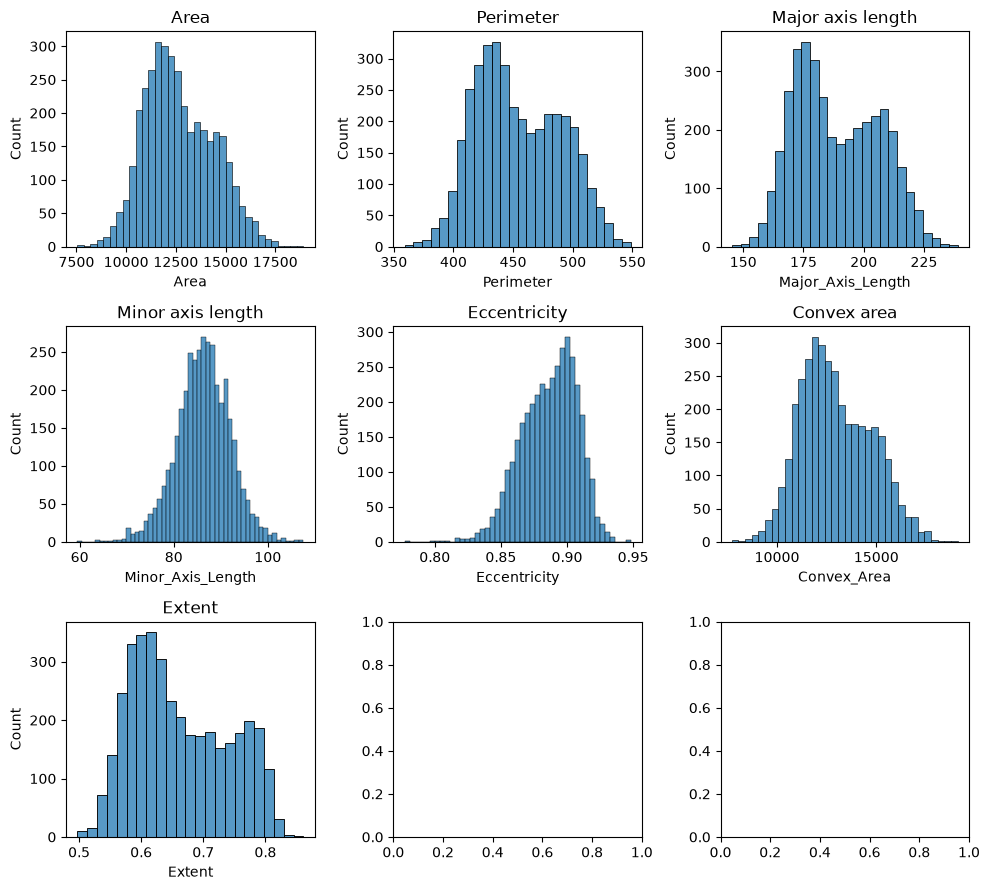

In [18]:
fig, axs = plt.subplots(3, 3, figsize=(10, 9))

sns.histplot(data=df, x='Area', ax=axs[0,0])
axs[0,0].set_title('Area')

sns.histplot(data=df, x='Perimeter', ax=axs[0,1])
axs[0,1].set_title('Perimeter')

sns.histplot(data=df, x='Major_Axis_Length', ax=axs[0,2])
axs[0,2].set_title('Major axis length')

sns.histplot(data=df, x='Minor_Axis_Length', ax=axs[1,0])
axs[1,0].set_title('Minor axis length')

sns.histplot(data=df, x='Eccentricity', ax=axs[1,1])
axs[1,1].set_title('Eccentricity')

sns.histplot(data=df, x='Convex_Area', ax=axs[1,2])
axs[1,2].set_title('Convex area')

sns.histplot(data=df, x='Extent', ax=axs[2,0])
axs[2,0].set_title('Extent')

plt.tight_layout()
plt.show()

In [19]:
features = df.columns.drop('Class')
features

Index(['Area', 'Perimeter', 'Major_Axis_Length', 'Minor_Axis_Length',
       'Eccentricity', 'Convex_Area', 'Extent'],
      dtype='str')

In [20]:
df[features].skew()

Area                 0.325158
Perimeter            0.221362
Major_Axis_Length    0.260242
Minor_Axis_Length   -0.134897
Eccentricity        -0.449249
Convex_Area          0.319782
Extent               0.343819
dtype: float64

**Skewness Analysis:** The feature distributions show mild skewness. Area, Perimeter, Major Axis Length, Convex Area and Extent exhibit mild positive skewness, while Minor Axis Length and Eccentricity exhibit negative skewness. Since the observed skewness is generally mild, no transformation will be applied solely based on skewness at this stage. Outliers, feature relationships and model requirements will be investigated before making final preprocessing decisions.

## Check outliers
Boxplot is used to find the outliers

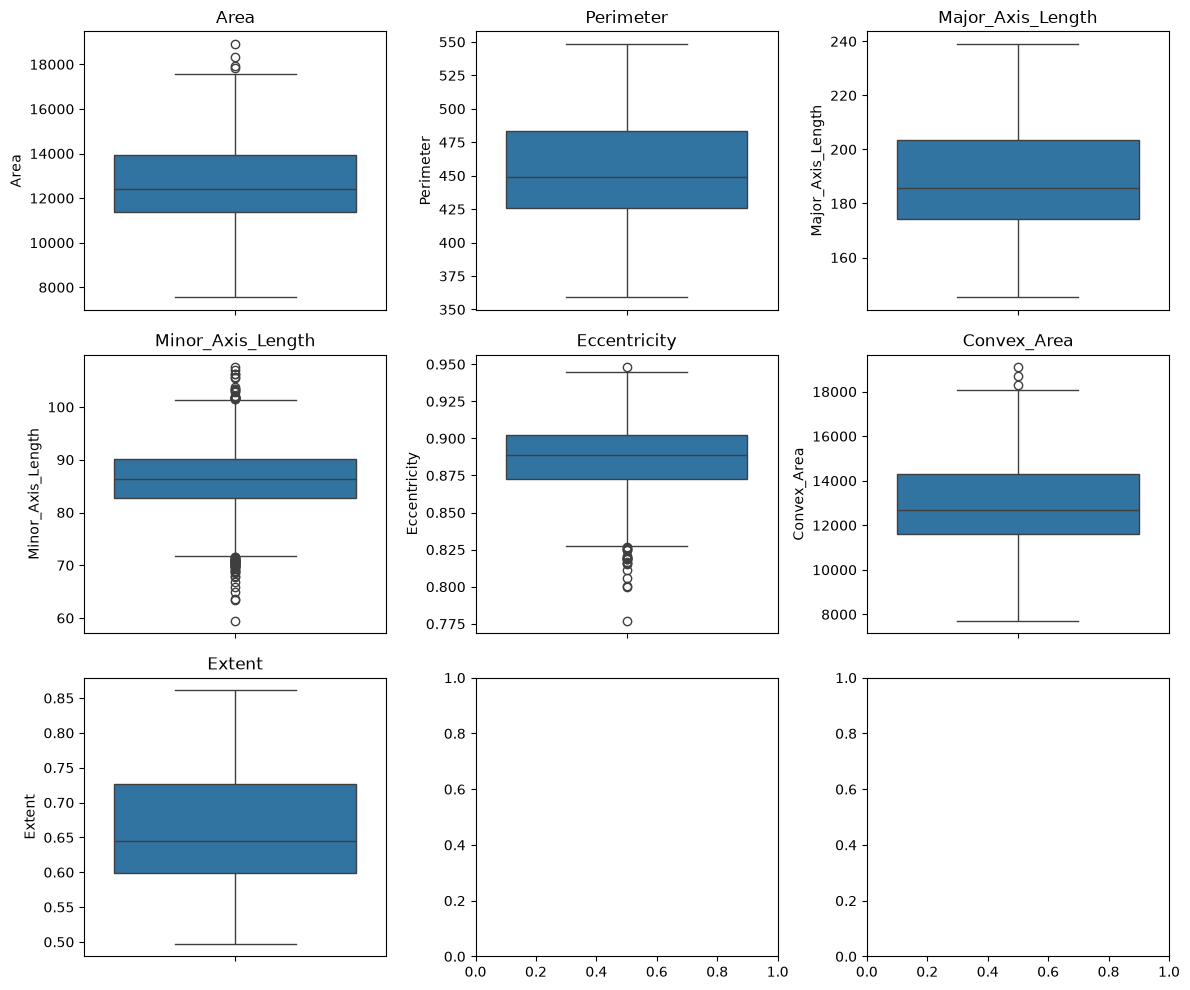

In [21]:
fig, axes = plt.subplots(3, 3, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(df.columns.drop('Class')):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)


plt.tight_layout()
plt.show()

Several features contain observations identified as potential outliers according to the IQR/boxplot criterion.

## Find how many outliers

In [22]:
Q1 = df[features].quantile(0.25)
Q3 = df[features].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outlier_mask = (df[features] < lower) | (df[features] > upper)

outlier_counts = outlier_mask.sum()

print(outlier_counts)

Area                  4
Perimeter             0
Major_Axis_Length     0
Minor_Axis_Length    65
Eccentricity         21
Convex_Area           3
Extent                0
dtype: int64


## Look at the actual outlier observations

In [23]:
outlier_rows = df[outlier_mask.any(axis=1)]

print(outlier_rows)

         Area   Perimeter  Major_Axis_Length  Minor_Axis_Length  Eccentricity  \
70    16490.0  520.318970         212.010757         101.680008      0.877488   
277   17948.0  526.918030         214.093826         107.542450      0.864685   
297   16431.0  509.385010         208.052872         101.961487      0.871680   
309   15517.0  481.377991         194.637512         102.058388      0.851502   
342   16412.0  515.114990         208.694550         101.941757      0.872579   
...       ...         ...                ...                ...           ...   
3584   8501.0  371.024994         153.896255          71.511909      0.885481   
3669   9722.0  373.752991         145.264465          87.054474      0.800538   
3674   8546.0  388.580994         172.519958          63.344753      0.930152   
3735   9426.0  402.709991         175.974289          68.607536      0.920869   
3809  11434.0  404.709991         161.079269          90.868195      0.825692   

      Convex_Area    Extent

# Actual outlier values

In [31]:
features_outliers = [
    "Area",
    "Minor_Axis_Length",
    "Eccentricity",
    "Convex_Area"
]

for col in features_outliers:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_values = df.loc[
        (df[col] < lower_bound) | (df[col] > upper_bound),
        col
    ]

    if len(outlier_values) > 0:
        print(f"\n{col}")
        print(outlier_values.to_list())


Area
[17948.0, 18313.0, 17856.0, 18913.0]

Minor_Axis_Length
[101.68000793457031, 107.54244995117188, 101.96148681640625, 102.05838775634766, 101.94175720214844, 101.4541015625, 67.69534301757812, 101.76990509033203, 106.18474578857422, 105.53797912597656, 102.90127563476562, 106.33782196044922, 70.77008056640625, 105.67058563232422, 101.51714324951172, 101.76249694824219, 103.36721801757812, 106.94835662841797, 103.24419403076172, 103.80493927001953, 101.64401245117188, 71.06098175048828, 103.35087585449219, 102.96282958984375, 101.65879821777344, 70.75994873046875, 68.986083984375, 68.90158081054688, 70.72579193115234, 69.93974304199219, 71.10741424560547, 70.63035583496094, 69.73334503173828, 70.1250228881836, 66.91815948486328, 69.40626525878906, 69.95188903808594, 70.568603515625, 70.25222778320312, 70.5107192993164, 64.8710708618164, 69.92797088623047, 70.45018005371094, 71.44275665283203, 65.9308853149414, 63.56500244140625, 71.0128402709961, 70.0859375, 59.532405853271484, 70.

### Outlier Analysis and Decision

The boxplot and IQR analysis identified potential outliers in several
morphological features:

- Area: 4 potential outliers
- Perimeter: 0 potential outliers
- Major_Axis_Length: 0 potential outliers
- Minor_Axis_Length: 65 potential outliers
- Eccentricity: 21 potential outliers
- Convex_Area: 3 potential outliers
- Extent: 0 potential outliers

The IQR method identifies observations that are statistically unusual,
but an IQR-based outlier does not necessarily indicate an erroneous
observation. Since these features represent physical measurements of
individual rice grains, extreme values may represent legitimate
variation rather than data errors.

Therefore, the identified potential outliers will be retained during
the EDA stage rather than being removed solely based on the IQR
criterion.

The potential impact of these observations will be considered during
the data preprocessing and modelling stages. Depending on the
requirements of the selected machine learning algorithms, appropriate
preprocessing techniques, such as suitable scaling methods, will be
evaluated without unnecessarily removing valid observations.

### Major Axis Length vs Minor Axis Length
Relationship between grain dimensions

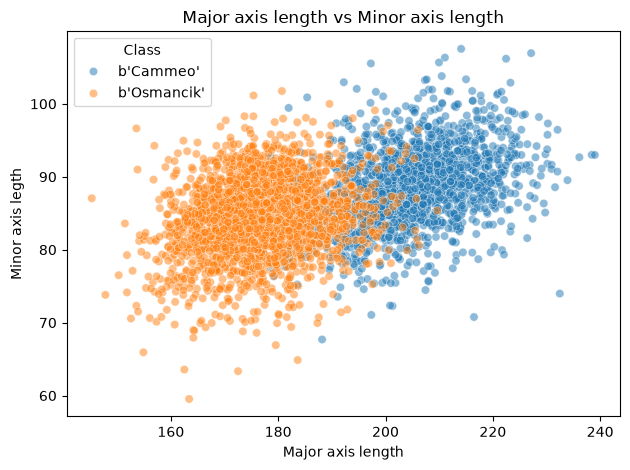

In [24]:
import seaborn as sns

sns.scatterplot(
    data=df,
    x='Major_Axis_Length',
    y='Minor_Axis_Length',
    hue='Class',
    alpha=0.5
)
plt.xlabel("Major axis length")
plt.ylabel("Minor axis legth")
plt.title('Major axis length vs Minor axis length')
plt.tight_layout()
plt.show()

Major Axis Length and Minor Axis Length exhibit a positive relationship. The two rice varieties show some separation in their distributions, although considerable overlap is present. This suggests that these features may contribute to rice-variety classification but may not be sufficient individually for complete class separation.

### Area vs Convex Area
Relationship between size-related measurements

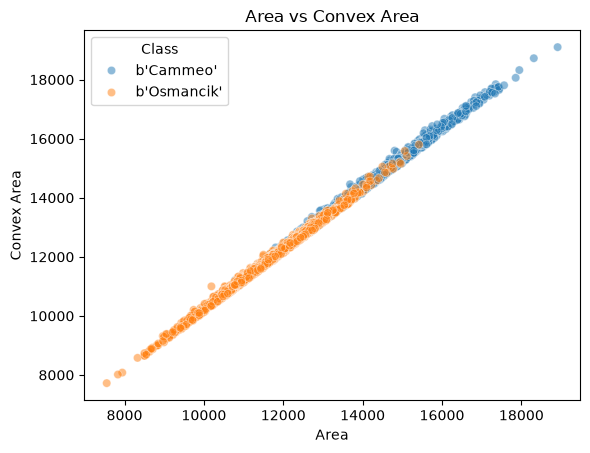

In [25]:
sns.scatterplot(
    data=df,
    x='Area',
    y='Convex_Area',
    hue='Class',
    alpha=0.5
)
plt.xlabel("Area")
plt.ylabel("Convex Area")
plt.title('Area vs Convex Area')
plt.show()

Area and Convex Area show a very strong positive, approximately linear relationship. This indicates that the two features may contain redundant information. Therefore, their correlation should be examined further before making a feature-selection decision.

### Area vs Perimeter
Size vs boundary relationship

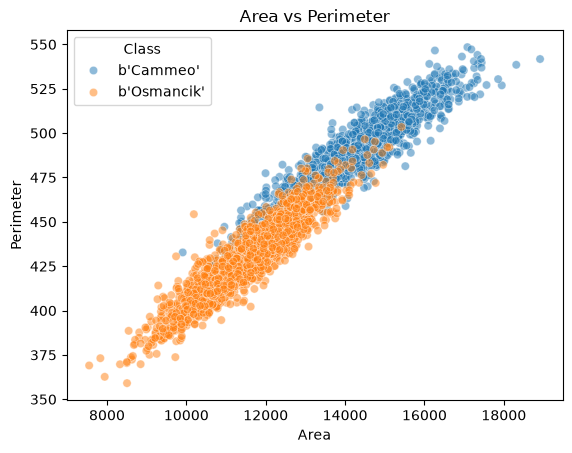

In [26]:
sns.scatterplot(
    data=df,
    x='Area',
    y='Perimeter',
    hue='Class',
    alpha=0.5
)
plt.xlabel("Area")
plt.ylabel("Perimeter")
plt.title('Area vs Perimeter')
plt.show()

Area and Perimeter exhibit a strong positive relationship, indicating that larger rice grains generally have larger perimeter measurements. The two rice varieties show some separation in the feature space, although considerable overlap remains. This suggests that Area and Perimeter may provide useful information for rice-variety classification. The strong relationship between Area and other size-related features will be further investigated using correlation analysis before making feature-selection decisions.

### Major Axis Length vs Eccentricity
Grain size vs shape

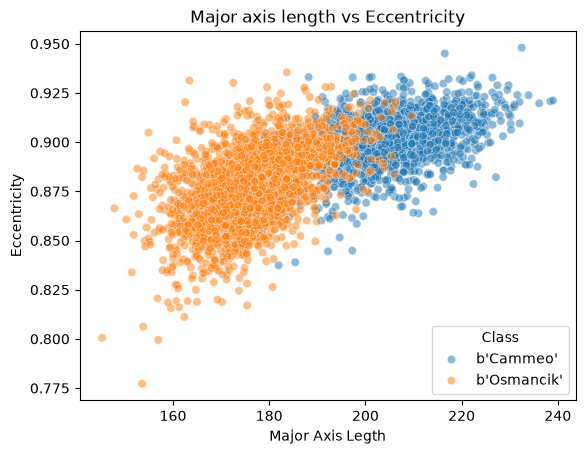

In [27]:
sns.scatterplot(
    data=df,
    x='Major_Axis_Length',
    y='Eccentricity',
    hue='Class',
    alpha=0.5
)
plt.xlabel("Major Axis Legth")
plt.ylabel("Eccentricity")
plt.title('Major axis length vs Eccentricity')
plt.show()

Major Axis Length and Eccentricity show a positive relationship. The class distributions exhibit some separation, with Cammeo generally occupying higher values of both features, although substantial overlap remains. This indicates that size and shape-related characteristics may jointly contribute to rice-variety classification.

# Correlation heatmap

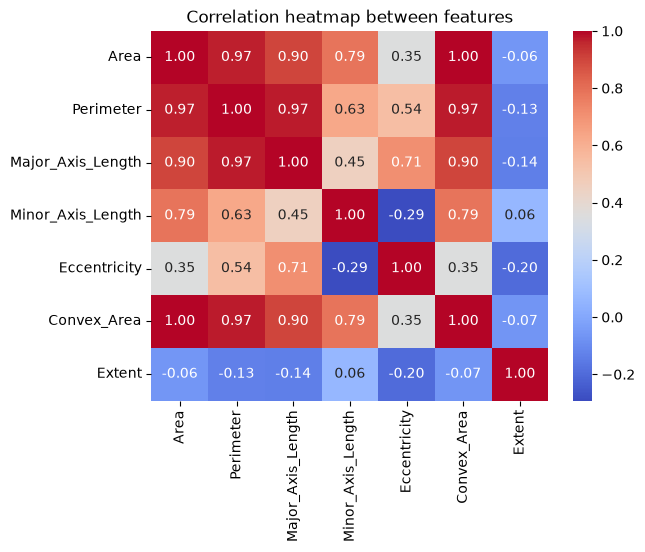

In [28]:
corr = df[features].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation heatmap between features")
plt.show()

Area and Convex Area show an extremely strong positive correlation (r = 1.00), indicating potential feature redundancy. This relationship will be considered during feature selection and model development.

# boxplots for all features by class

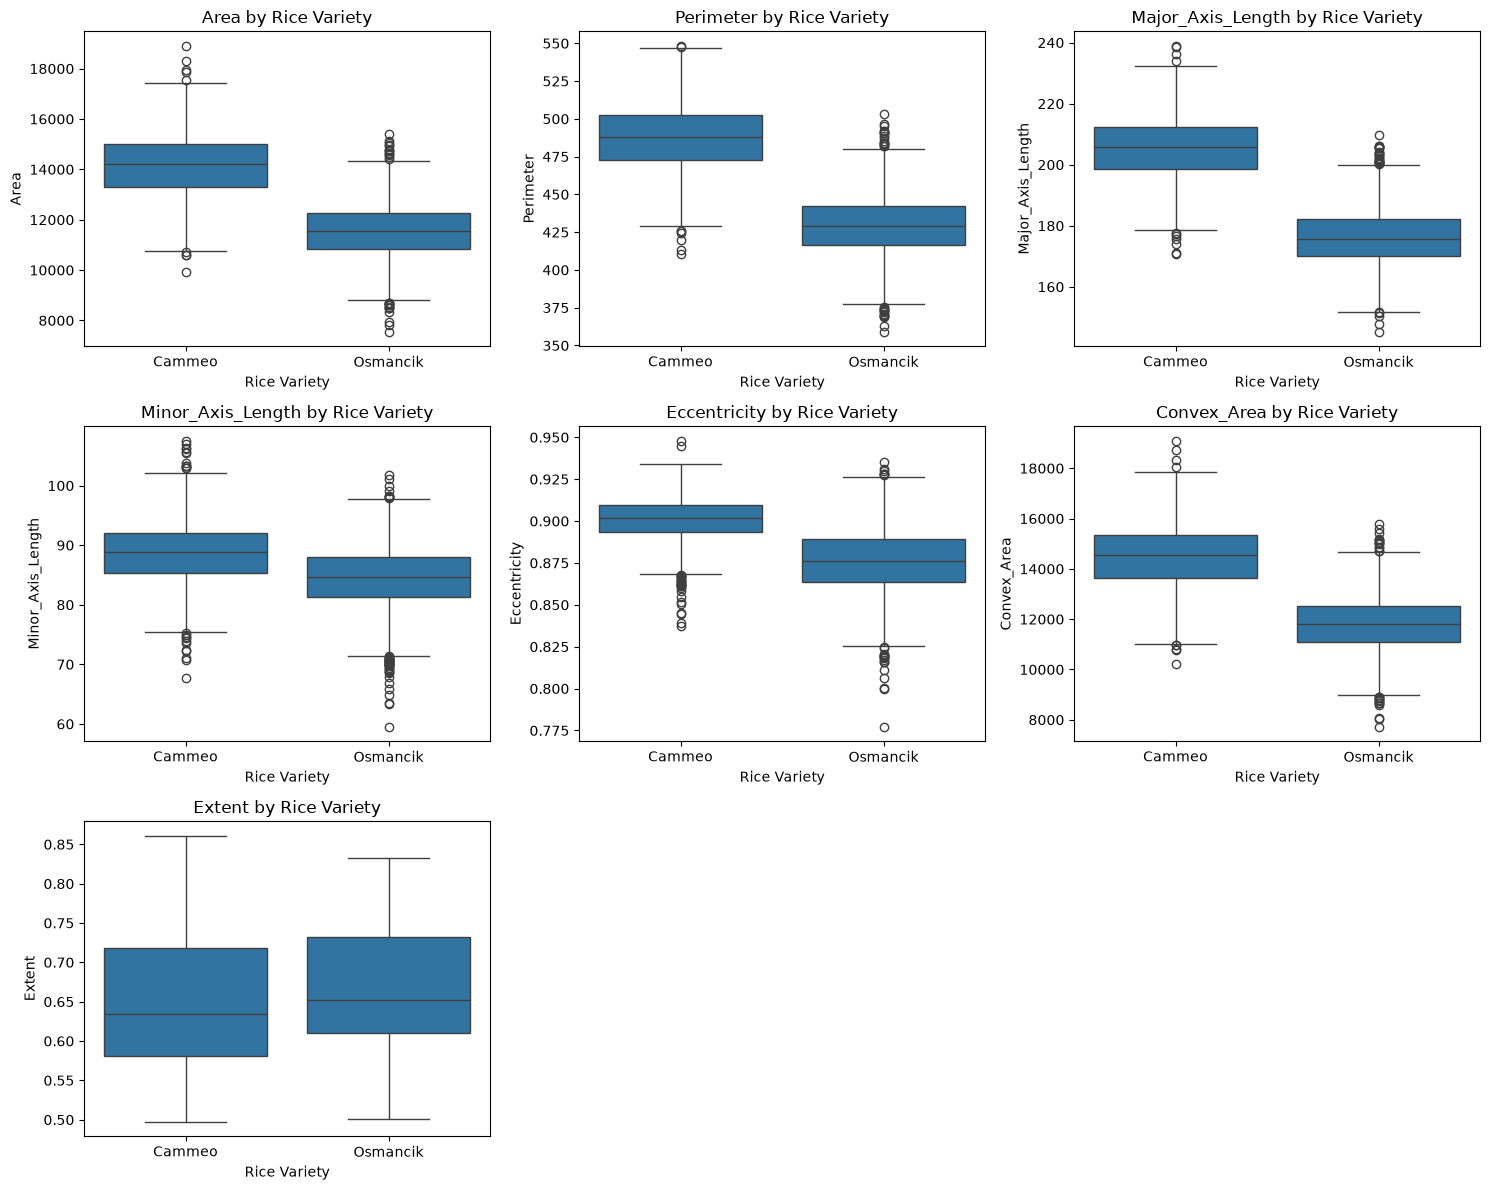

In [29]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

for ax, feature in zip(axes.flatten(), features):
    sns.boxplot(
        data=df,
        x="Class",
        y=feature,
        ax=ax
    )
    ax.set_title(f"{feature} by Rice Variety")
    ax.set_xlabel("Rice Variety")
    ax.set_ylabel(feature)

# Hide unused subplots
for ax in axes.flatten()[len(features):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

### Class-wise Feature Distribution Analysis

Boxplots were used to compare the distributions of the seven
morphological features between the Cammeo and Osmancik rice varieties.

Area, Perimeter, Major Axis Length, Minor Axis Length, Eccentricity,
and Convex Area show noticeable differences between the two classes,
with Cammeo generally exhibiting higher values than Osmancik. However,
some overlap between the class distributions is present, indicating
that individual features may not be sufficient to completely
distinguish the two rice varieties.

Extent shows substantially greater overlap between the two classes,
with less obvious separation than the other features. However, this
does not imply that Extent is irrelevant, and its contribution will
be evaluated during feature selection and model development.

The analysis also shows potential outlying observations within several
features for both classes. These observations will not be removed
solely based on the IQR criterion and will be considered further
during preprocessing.

Overall, the class-wise distributions indicate that the morphological
features contain useful information for distinguishing Cammeo and
Osmancik, supporting the proposed binary classification task.